# Human Development Index (HDI) Prediction
### Machine Learning + Flask End-to-End Project

This notebook walks through the full ML lifecycle to build a **Linear Regression** model that predicts a country's **HDI score** from four indicators:
1. Life expectancy
2. Mean years of schooling
3. Expected years of schooling
4. Gross National Income (GNI) per capita

Workflow covered:
- Epic 2: Import libraries
- Epic 3: Dataset understanding & visualization
- Epic 4: Data preprocessing & label encoding
- Epic 5: Train / Test split
- Epic 6: Fit Linear Regression & evaluate
- Epic 7: Save the model with Pickle

## Epic 2 — Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pickle

import warnings
warnings.filterwarnings('ignore')

# Display plots inline and set a clean style
%matplotlib inline
sns.set_style('whitegrid')
print('All libraries imported successfully.')

All libraries imported successfully.


## Epic 3 — Dataset Download and Understanding

### Story 1 & 2: Load the dataset and explore its structure

In [2]:
# Load the HDI dataset
df = pd.read_csv('../Dataset/HDI.csv')
df.head()

,Country,Life expectancy,Mean years of schooling,Expected years of schooling,Gross National Income (GNI) per capita,HDI
0,Norway,82.6,12.9,18.2,66000,0.960
1,Switzerland,84.3,13.9,16.5,70000,0.966
2,Ireland,82.8,12.7,19.7,68371,0.974
3,Germany,81.3,14.1,17.1,47000,0.939
4,Hong Kong,85.5,12.2,17.3,62967,0.955


In [3]:
# Shape of the dataset
print('Rows    :', df.shape[0])
print('Columns :', df.shape[1])

Rows    : 124
Columns : 6


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 124 non-null    str    
 1   Life expectancy                         124 non-null    float64
 2   Mean years of schooling                 124 non-null    float64
 3   Expected years of schooling             124 non-null    float64
 4   Gross National Income (GNI) per capita  124 non-null    int64  
 5   HDI                                     124 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 5.9 KB


In [5]:
# Statistical summary of numeric features
df.describe()

,Life expectancy,Mean years of schooling,Expected years of schooling,Gross National Income (GNI) per capita,HDI
count,124.000000,124.000000,124.00000,124.000000,124.000000
mean,74.086290,9.203226,13.83871,23388.129032,0.750306
std,7.515278,3.190584,3.30168,21328.989380,0.160610
min,53.100000,1.800000,5.40000,800.000000,0.365000
25%,69.625000,7.150000,11.57500,5900.000000,0.639750
50%,75.750000,9.500000,14.00000,14500.000000,0.773500
75%,80.100000,12.125000,16.40000,37378.750000,0.882500
max,85.500000,14.100000,21.90000,92000.000000,0.986000


### Story 3: Data Visualization

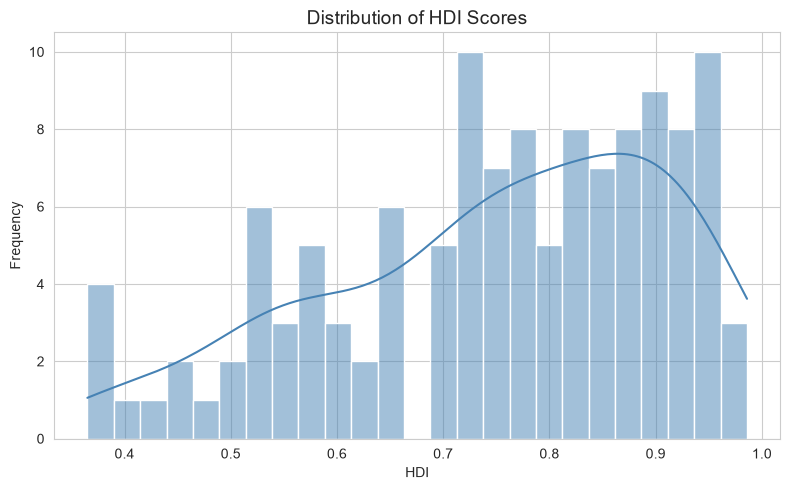

In [6]:
# Distribution of the target variable (HDI)
plt.figure(figsize=(8, 5))
sns.histplot(df['HDI'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of HDI Scores', fontsize=14)
plt.xlabel('HDI')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

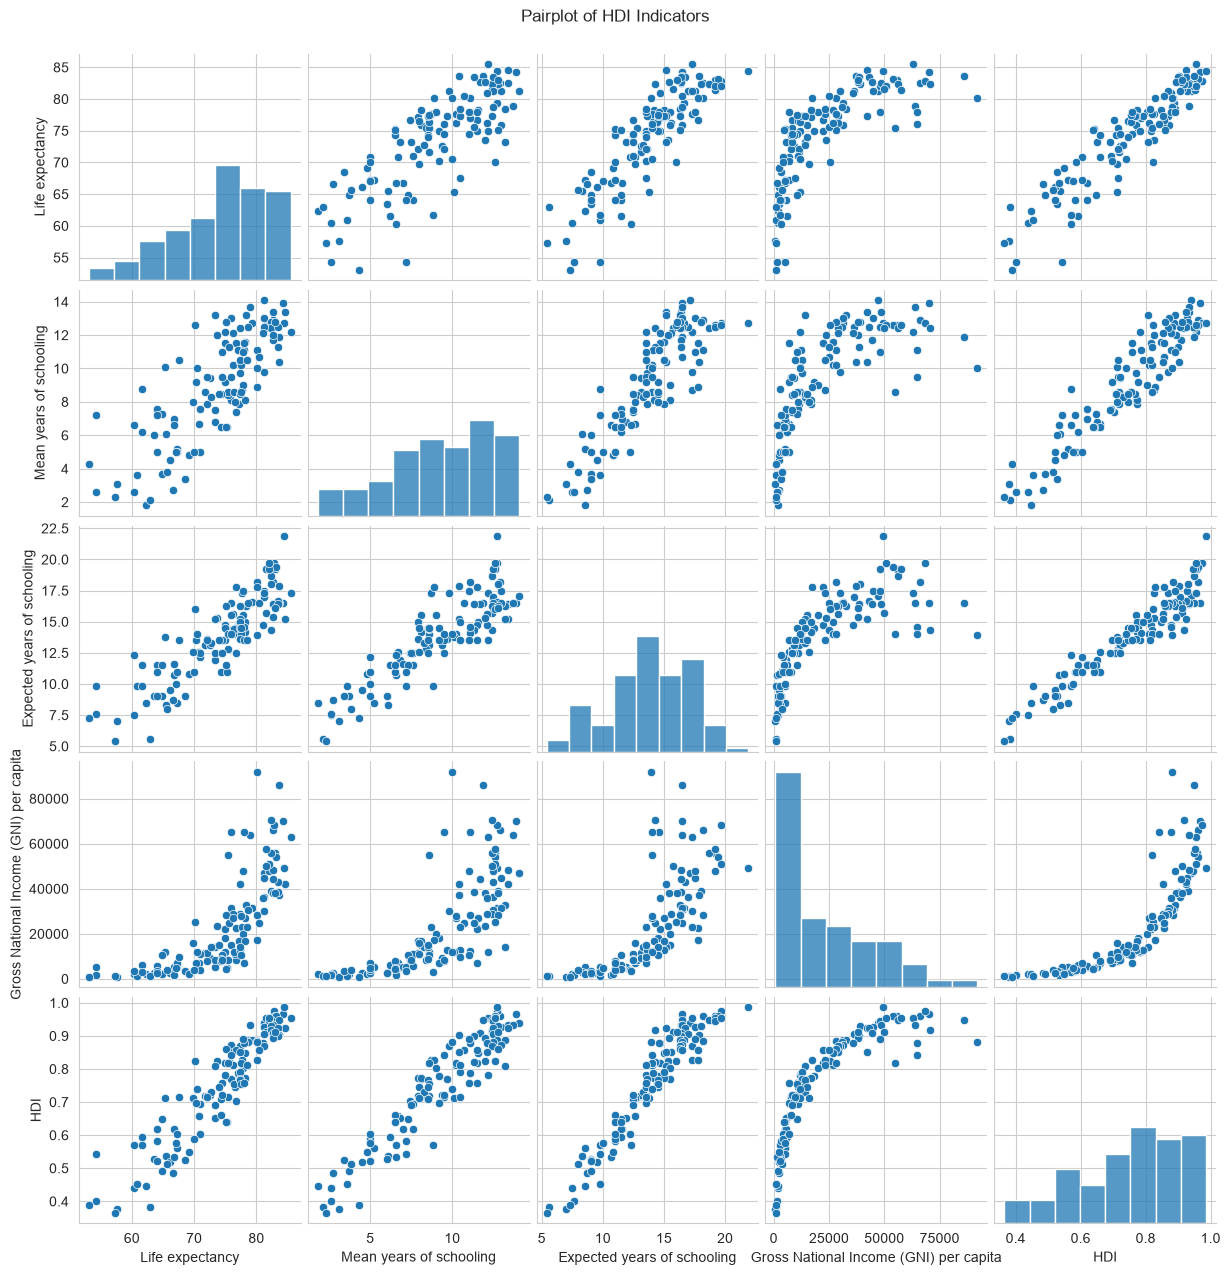

In [7]:
# Pairwise relationships between indicators and HDI
sns.pairplot(df.drop(columns=['Country']))
plt.suptitle('Pairplot of HDI Indicators', y=1.02)
plt.show()

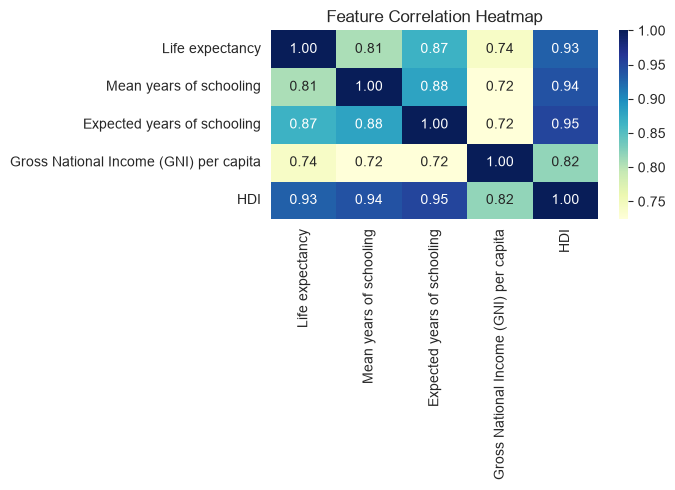

In [8]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df.drop(columns=['Country']).corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Epic 4 — Data Preprocessing and Label Encoding

### Story 1: Select dependent and independent variables

- **Independent variables (X):** Life expectancy, Mean years of schooling, Expected years of schooling, GNI per capita
- **Dependent variable (y):** HDI

In [9]:
# Independent features
X = df[['Life expectancy',
        'Mean years of schooling',
        'Expected years of schooling',
        'Gross National Income (GNI) per capita']]

# Target variable
y = df['HDI']

X.head()

,Life expectancy,Mean years of schooling,Expected years of schooling,Gross National Income (GNI) per capita
0,82.6,12.9,18.2,66000
1,84.3,13.9,16.5,70000
2,82.8,12.7,19.7,68371
3,81.3,14.1,17.1,47000
4,85.5,12.2,17.3,62967


### Story 2: Check for missing values

In [11]:
# Check for nulls across the whole dataset
df.isnull().sum()

Country                                   0
Life expectancy                           0
Mean years of schooling                   0
Expected years of schooling               0
Gross National Income (GNI) per capita    0
HDI                                       0
dtype: int64

### Story 3: Label Encoding

The `Country` column is categorical text. We convert it to numerical labels so it can be used/saved alongside the model. The numeric indicators (already numeric) feed the regression directly.

In [ ]:
# Label-encode the Country column (categorical -> numeric)
le = LabelEncoder()
df['Country_encoded'] = le.fit_transform(df['Country'])

# Preview encoded values
df[['Country', 'Country_encoded']].head(10)

### Story 4: Confirm the cleaned dataset is ready

In [12]:
print('Final feature matrix shape :', X.shape)
print('Target vector shape        :', y.shape)
df_clean = X.copy()
df_clean['HDI'] = y
df_clean.head()

Final feature matrix shape : (124, 4)
Target vector shape        : (124,)


,Life expectancy,Mean years of schooling,Expected years of schooling,Gross National Income (GNI) per capita,HDI
0,82.6,12.9,18.2,66000,0.960
1,84.3,13.9,16.5,70000,0.966
2,82.8,12.7,19.7,68371,0.974
3,81.3,14.1,17.1,47000,0.939
4,85.5,12.2,17.3,62967,0.955


## Epic 5 — Train / Test Split

Split the data so the model learns on one portion and is evaluated on unseen data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples :', X_train.shape[0])
print('Testing samples  :', X_test.shape[0])

Training samples : 99
Testing samples  : 25


## Epic 6 — Fitting the Model

### Story 1: Train the Linear Regression model

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained successfully.')
print('Coefficients :', model.coef_)
print('Intercept    :', model.intercept_)

Model trained successfully.
Coefficients : [6.08632947e-03 1.74546919e-02 1.50397828e-02 9.27117830e-07]
Intercept    : -0.0910916756735548


### Story 2: Generate predictions

In [15]:
y_pred = model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(3)})
comparison.head(10)

,Actual,Predicted
0,0.924,0.926
1,0.825,0.818
2,0.847,0.838
3,0.388,0.418
4,0.718,0.703
5,0.731,0.709
6,0.714,0.715
7,0.841,0.808
8,0.575,0.560
9,0.955,0.961


### Story 3: Evaluate model performance

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE) : {mae:.4f}')
print(f'Mean Squared Error (MSE)  : {mse:.6f}')
print(f'Root Mean Squared Error   : {rmse:.4f}')
print(f'R-squared (R2) Score      : {r2:.4f}')

Mean Absolute Error (MAE) : 0.0136
Mean Squared Error (MSE)  : 0.000260
Root Mean Squared Error   : 0.0161
R-squared (R2) Score      : 0.9889


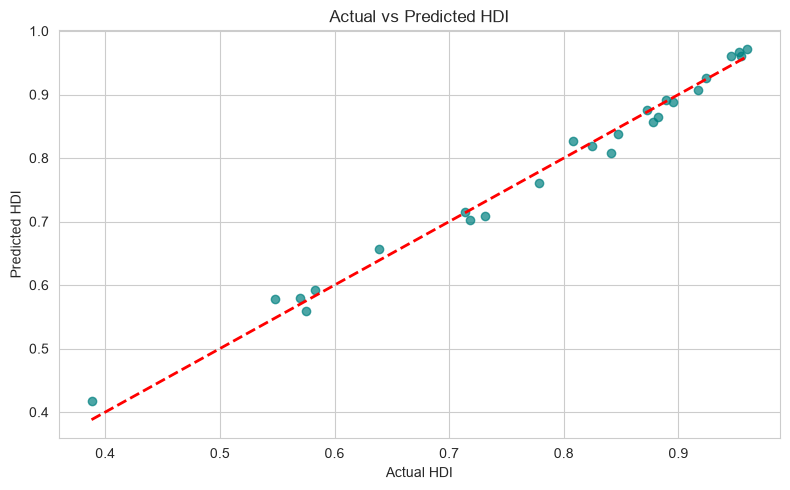

In [17]:
# Visualize actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual HDI')
plt.ylabel('Predicted HDI')
plt.title('Actual vs Predicted HDI')
plt.tight_layout()
plt.show()

## Epic 7 — Saving the Model

### Story 1 & 2: Serialize with Pickle for reuse and deployment

In [20]:
# Save the trained model so the Flask app can load it without retraining
with open('../Flask/HDI.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Model saved to ../Flask/HDI.pkl')

# Quick sanity-check: reload and predict a sample
with open('../Flask/HDI.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = pd.DataFrame([[82.6, 12.9, 18.2, 66000]],
                      columns=X.columns)
pred = loaded_model.predict(sample)[0]
print(f'Sample prediction (Norway-like): HDI = {pred:.3f}')

Model saved to ../Flask/HDI.pkl
Sample prediction (Norway-like): HDI = 0.972


---

### ✅ Pipeline complete
The trained Linear Regression model has been saved as `HDI.pkl`.
The next step (Epic 8) is to build the Flask web application that uses this model to serve live HDI predictions to users.